# Project 01 — Deepfake Video Detection (DFDC)
### Spatiotemporal Adapter (STA) · EfficientNet-B4 · Swin Transformer
> Run cells top to bottom. Do NOT skip any cell.

In [3]:
# ── CELL 1: Install dependencies ─────────────────────────────────────────────
!pip install -q timm opencv-python-headless pyyaml scikit-learn pandas matplotlib
print("All dependencies installed.")

ERROR: allennlp 0.9.0 requires flaky, which is not installed.
ERROR: allennlp 0.9.0 requires responses>=0.7, which is not installed.
ERROR: chainer 6.5.0 has requirement typing-extensions<=3.6.6, but you'll have typing-extensions 4.1.1 which is incompatible.
ERROR: allennlp 0.9.0 has requirement spacy<2.2,>=2.1.0, but you'll have spacy 2.2.3 which is incompatible.
All dependencies installed.


In [5]:
# ── CELL 2: Configuration ─────────────────────────────────────────────────────
# Edit settings here before training.

CFG = {
    "data": {
        "root": "/kaggle/input/competitions/deepfake-detection-challenge/train_sample_videos",
        "num_parts": 5,          # Start with 5. Use 50 for full training.
        "max_per_part": None,    # Set e.g. 200 for a quick sanity check run.
        "face_size": 224,
        "frames_per_video": 8,
        "val_split": 0.15,
        "num_workers": 2,
    },
    "model": {
        "spatial_backbone": "efficientnet_b4",
        "temporal_backbone": "swin_tiny_patch4_window7_224",
        "sta_hidden_dim": 256,
        "bank_size": 512,
        "dropout": 0.3,
        "pretrained": True,
    },
    "training": {
        "epochs": 10,
        "batch_size": 16,        # Reduce to 8 if you see CUDA out of memory.
        "learning_rate": 0.0001,
        "weight_decay": 0.0001,
        "warmup_epochs": 1,
        "bce_weight": 1.0,
        "orthogonal_loss_weight": 0.1,
        "contrastive_loss_weight": 0.1,
        "use_amp": True,
        "grad_clip": 1.0,
        "save_every": 1,
        "checkpoint_dir": "/kaggle/working/checkpoints",
    },
    "evaluation": {
        "results_dir": "/kaggle/working/results",
        "threshold": 0.5,
        "compute_eer": True,
    },
    "logging": {
        "wandb_api_key": None,   # Paste your W&B key here as a string, or leave None.
        "wandb_project": "dfdc-deepfake-detection",
        "wandb_run_name": "sta-efficientnet-swin",
        "log_interval": 50,
    },
}

print("Configuration loaded.")
print(f"  Parts to use    : {CFG['data']['num_parts']} / 50")
print(f"  Frames/video    : {CFG['data']['frames_per_video']}")
print(f"  Batch size      : {CFG['training']['batch_size']}")
print(f"  Epochs          : {CFG['training']['epochs']}")
print(f"  AMP             : {CFG['training']['use_amp']}")

Configuration loaded.
  Parts to use    : 5 / 50
  Frames/video    : 8
  Batch size      : 16
  Epochs          : 10
  AMP             : True


In [6]:
# ── CELL 3: Imports and device setup ──────────────────────────────────────────
import os
import sys
import json
import random
import math
import time
import numpy as np
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix
)

MTCNN_AVAILABLE = False
print("Using center crop fallback for face extraction.")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Using center crop fallback for face extraction.
Device: cuda
GPU: Tesla P100-PCIE-16GB
VRAM: 17.1 GB


In [8]:
# ── CELL 4: Dataset — transforms ─────────────────────────────────────────────

def get_train_transforms(face_size=224):
    return transforms.Compose([
        transforms.Resize((face_size, face_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

def get_val_transforms(face_size=224):
    return transforms.Compose([
        transforms.Resize((face_size, face_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

print("Transforms defined.")

Transforms defined.


In [9]:
# ── CELL 5: Dataset — FaceExtractor ──────────────────────────────────────────

class FaceExtractor:
    def __init__(self, face_size=224, device="cpu"):
        self.face_size = face_size
        self.device = device
        if MTCNN_AVAILABLE:
            self.detector = MTCNN(
                image_size=face_size, margin=20,
                keep_all=False, post_process=False,
                device=device, select_largest=True,
            )
        else:
            self.detector = None

    def extract_from_frame(self, frame_bgr):
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(frame_rgb)
        if self.detector is not None:
            try:
                face = self.detector(pil_img)
                if face is not None:
                    face_np = face.permute(1, 2, 0).numpy()
                    face_np = np.clip(face_np, 0, 255).astype(np.uint8)
                    return Image.fromarray(face_np)
            except Exception:
                pass
        # Fallback: center crop
        w, h = pil_img.size
        min_dim = min(w, h)
        left = (w - min_dim) // 2
        top  = (h - min_dim) // 2
        pil_img = pil_img.crop((left, top, left + min_dim, top + min_dim))
        return pil_img.resize((self.face_size, self.face_size))

print("FaceExtractor defined.")

FaceExtractor defined.


In [10]:
# ── CELL 6: Dataset — frame sampler ──────────────────────────────────────────

def sample_frames_from_video(video_path, num_frames=8, face_extractor=None, face_size=224):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < num_frames:
        indices = list(range(total_frames))
    else:
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int).tolist()
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        if face_extractor is not None:
            face = face_extractor.extract_from_frame(frame)
            if face is not None:
                frames.append(face)
        else:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(Image.fromarray(frame_rgb).resize((face_size, face_size)))
    cap.release()
    while len(frames) < num_frames and len(frames) > 0:
        frames.append(frames[-1])
    return frames if len(frames) > 0 else None

print("Frame sampler defined.")

Frame sampler defined.


In [11]:
# ── CELL 7: Dataset — DFDCDataset class (adjusted for sample data) ────────────

class DFDCDataset(Dataset):
    def __init__(self, root_dir, num_parts=5, num_frames=8, face_size=224,
                 transform=None, split="train", val_split=0.15,
                 max_per_part=None, seed=42, device="cpu"):
        self.root_dir   = Path(root_dir)
        self.num_frames = num_frames
        self.face_size  = face_size
        self.transform  = transform
        self.split      = split
        self.face_extractor = FaceExtractor(face_size=face_size, device=device)
        self.samples = []
        self._collect_samples(max_per_part)
        random.seed(seed)
        random.shuffle(self.samples)
        n_val = int(len(self.samples) * val_split)
        self.samples = self.samples[:n_val] if split == "val" else self.samples[n_val:]
        labels = [s[1] for s in self.samples]
        print(f"[DFDCDataset] {split}: {len(self.samples)} videos "
              f"({sum(1 for l in labels if l==0)} REAL, {sum(labels)} FAKE)")

    def _collect_samples(self, max_per_part):
        # train_sample_videos has metadata.json directly in the folder
        meta_path = self.root_dir / "metadata.json"
        if not meta_path.exists():
            raise FileNotFoundError(
                f"metadata.json not found in {self.root_dir}\n"
                f"Contents: {list(self.root_dir.iterdir())[:10]}"
            )
        with open(meta_path) as f:
            metadata = json.load(f)
        for filename, info in metadata.items():
            video_path = self.root_dir / filename
            if not video_path.exists():
                continue
            label = 1 if info.get("label", "REAL") == "FAKE" else 0
            self.samples.append((str(video_path), label))
        if max_per_part is not None:
            random.shuffle(self.samples)
            self.samples = self.samples[:max_per_part]
        print(f"Found {len(self.samples)} videos in {self.root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        frames = sample_frames_from_video(
            video_path, num_frames=self.num_frames,
            face_extractor=self.face_extractor, face_size=self.face_size
        )
        if frames is None or len(frames) == 0:
            dummy = torch.zeros(self.num_frames, 3, self.face_size, self.face_size)
            return {"frames": dummy,
                    "label": torch.tensor(label, dtype=torch.float32),
                    "path": video_path}
        if self.transform is not None:
            frames = [self.transform(f) for f in frames]
        else:
            to_t = transforms.Compose([
                transforms.Resize((self.face_size, self.face_size)),
                transforms.ToTensor()
            ])
            frames = [to_t(f) for f in frames]
        return {
            "frames": torch.stack(frames, dim=0),
            "label":  torch.tensor(label, dtype=torch.float32),
            "path":   video_path,
        }

print("DFDCDataset defined.")

DFDCDataset defined.


In [12]:
# ── CELL 8: Model — Spatiotemporal Adapter (STA) ──────────────────────────────

class SpatiotemporalAdapter(nn.Module):
    def __init__(self, in_dim, hidden_dim=256):
        super().__init__()
        self.spatial_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(), nn.LayerNorm(hidden_dim)
        )
        self.temporal_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(), nn.LayerNorm(hidden_dim)
        )

    def forward(self, x):
        return self.spatial_proj(x), self.temporal_proj(x)

    @staticmethod
    def orthogonal_loss(s, t):
        s_norm = F.normalize(s, dim=-1)
        t_norm = F.normalize(t, dim=-1)
        return ((s_norm * t_norm).sum(dim=-1) ** 2).mean()

print("SpatiotemporalAdapter defined.")

SpatiotemporalAdapter defined.


In [14]:
# ── CELL 9: Model — Contrastive Feature Bank ──────────────────────────────────

class ContrastiveFeatureBank(nn.Module):
    def __init__(self, feature_dim, bank_size=512):
        super().__init__()
        self.feature_dim = feature_dim
        self.bank_size   = bank_size
        self.register_buffer("real_bank", torch.randn(bank_size, feature_dim))
        self.register_buffer("fake_bank", torch.randn(bank_size, feature_dim))
        self.register_buffer("real_ptr",  torch.zeros(1, dtype=torch.long))
        self.register_buffer("fake_ptr",  torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def update(self, features, labels):
        for feat, lbl in zip(features, labels):
            feat = F.normalize(feat.unsqueeze(0), dim=-1)
            if lbl.item() == 0:
                ptr = int(self.real_ptr)
                self.real_bank[ptr] = feat.squeeze()
                self.real_ptr[0] = (ptr + 1) % self.bank_size
            else:
                ptr = int(self.fake_ptr)
                self.fake_bank[ptr] = feat.squeeze()
                self.fake_ptr[0] = (ptr + 1) % self.bank_size

    def contrastive_loss(self, features, labels, temperature=0.07):
        feat_norm  = F.normalize(features, dim=-1)
        real_proto = F.normalize(self.real_bank.mean(0, keepdim=True), dim=-1)
        fake_proto = F.normalize(self.fake_bank.mean(0, keepdim=True), dim=-1)
        sim = torch.cat([
            (feat_norm * real_proto).sum(-1, keepdim=True),
            (feat_norm * fake_proto).sum(-1, keepdim=True),
        ], dim=-1) / temperature
        return F.cross_entropy(sim, labels.long())

print("ContrastiveFeatureBank defined.")

ContrastiveFeatureBank defined.


In [15]:
# ── CELL 10: Model — Spatial Encoder (EfficientNet-B4) ────────────────────────

class SpatialEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b4", pretrained=pretrained,
            num_classes=0, global_pool="avg"
        )
        self.out_dim = self.backbone.num_features  # 1792

    def forward(self, x):
        return self.backbone(x)

print("SpatialEncoder defined.")

SpatialEncoder defined.


In [24]:
# ── CELL 11: Model — Temporal Encoder (Transformer over frame features) ────────

class TemporalEncoder(nn.Module):
    def __init__(self, spatial_dim, num_frames=8, pretrained=True):
        super().__init__()
        self.num_frames = num_frames
        swin_dim = 768  # swin_tiny output dim
        self.input_proj = nn.Linear(spatial_dim, swin_dim)
        self.pos_embed  = nn.Parameter(torch.randn(1, num_frames, swin_dim) * 0.02)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=swin_dim, nhead=8, dim_feedforward=swin_dim * 4,
            dropout=0.1, activation="gelu", batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.out_dim = swin_dim

    def forward(self, spatial_feats):
        x = self.input_proj(spatial_feats)
        x = x + self.pos_embed[:, :x.size(1)]
        x = self.transformer(x)
        return x.mean(dim=1)

print("TemporalEncoder defined.")

TemporalEncoder defined.


In [25]:
# ── CELL 12: Model — Full DeepfakeDetector ────────────────────────────────────

class DeepfakeDetector(nn.Module):
    def __init__(self, num_frames=8, face_size=224, sta_hidden_dim=256,
                 bank_size=512, dropout=0.3, pretrained=True):
        super().__init__()
        self.num_frames  = num_frames
        self.spatial_enc = SpatialEncoder(pretrained=pretrained)
        self.temporal_enc = TemporalEncoder(
            spatial_dim=self.spatial_enc.out_dim,
            num_frames=num_frames, pretrained=pretrained
        )
        fused_dim = self.spatial_enc.out_dim + self.temporal_enc.out_dim
        self.sta  = SpatiotemporalAdapter(in_dim=fused_dim, hidden_dim=sta_hidden_dim)
        self.bank = ContrastiveFeatureBank(feature_dim=sta_hidden_dim * 2, bank_size=bank_size)
        self.classifier = nn.Sequential(
            nn.Linear(sta_hidden_dim * 2, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

    def forward(self, frames, labels=None):
        B, T, C, H, W = frames.shape
        spatial_flat  = self.spatial_enc(frames.view(B * T, C, H, W))
        spatial       = spatial_flat.view(B, T, -1)
        temporal      = self.temporal_enc(spatial)
        spatial_mean  = spatial.mean(dim=1)
        fused         = torch.cat([spatial_mean, temporal], dim=-1)
        s_tokens, t_tokens = self.sta(fused)
        combined      = torch.cat([s_tokens, t_tokens], dim=-1)
        logits        = self.classifier(combined).squeeze(-1)
        probs         = torch.sigmoid(logits)
        losses = {}
        if self.training and labels is not None:
            losses["bce"]         = F.binary_cross_entropy_with_logits(logits, labels)
            losses["orthogonal"]  = SpatiotemporalAdapter.orthogonal_loss(s_tokens, t_tokens)
            losses["contrastive"] = self.bank.contrastive_loss(combined, labels)
            self.bank.update(combined.detach(), labels)
        return {"logits": logits, "probs": probs,
                "combined_features": combined, "losses": losses}

    def get_cam_target_layer(self):
        return self.spatial_enc.backbone.conv_head

print("DeepfakeDetector defined.")

DeepfakeDetector defined.


In [17]:
# ── CELL 13: Training utilities ───────────────────────────────────────────────

class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.min_lr        = min_lr
        super().__init__(optimizer, last_epoch)
    def get_lr(self):
        e = self.last_epoch
        if e < self.warmup_epochs:
            factor = (e + 1) / self.warmup_epochs
        else:
            progress = (e - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            factor   = 0.5 * (1 + math.cos(math.pi * progress))
        return [max(self.min_lr, base_lr * factor) for base_lr in self.base_lrs]

class MetricsTracker:
    def __init__(self): self.reset()
    def reset(self):
        self.losses, self.all_probs, self.all_labels = [], [], []
    def update(self, loss, probs, labels):
        self.losses.append(loss)
        self.all_probs.extend(probs.detach().cpu().numpy().tolist())
        self.all_labels.extend(labels.detach().cpu().numpy().tolist())
    def compute(self):
        probs  = np.array(self.all_probs)
        labels = np.array(self.all_labels)
        auc = 0.0
        try:
            if len(np.unique(labels)) == 2:
                auc = roc_auc_score(labels, probs)
        except Exception: pass
        preds = (probs >= 0.5).astype(int)
        acc   = (preds == labels).mean()
        tp = ((preds==1)&(labels==1)).sum(); fp = ((preds==1)&(labels==0)).sum()
        fn = ((preds==0)&(labels==1)).sum()
        prec = tp / (tp + fp + 1e-8); rec = tp / (tp + fn + 1e-8)
        f1   = 2 * prec * rec / (prec + rec + 1e-8)
        return {"loss": np.mean(self.losses), "auc": auc,
                "acc": acc, "f1": f1, "precision": prec, "recall": rec}

def save_checkpoint(model, optimizer, scheduler, scaler, epoch, metrics, cfg):
    ckpt_dir = Path(cfg["training"]["checkpoint_dir"])
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / f"epoch_{epoch:02d}_auc{metrics['auc']:.4f}.pt"
    torch.save({
        "epoch": epoch, "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if scaler else None,
        "metrics": metrics, "config": cfg,
    }, ckpt_path)
    print(f"  ✓ Saved: {ckpt_path.name}")
    return ckpt_path

print("Training utilities defined.")

Training utilities defined.


In [18]:
# ── CELL 14: Train one epoch function ─────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, scaler, cfg, device, epoch, wandb_run=None):
    model.train()
    tracker = MetricsTracker()
    t = cfg["training"]
    log_interval = cfg["logging"]["log_interval"]
    bce_w, orth_w, cont_w = t["bce_weight"], t["orthogonal_loss_weight"], t["contrastive_loss_weight"]

    for step, batch in enumerate(loader):
        frames = batch["frames"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)
        optimizer.zero_grad()

        with autocast(enabled=(scaler is not None)):
            output = model(frames, labels)
            losses = output["losses"]
            total_loss = (bce_w * losses["bce"]
                        + orth_w * losses["orthogonal"]
                        + cont_w * losses["contrastive"])

        if scaler is not None:
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), t["grad_clip"])
            scaler.step(optimizer)
            scaler.update()
        else:
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), t["grad_clip"])
            optimizer.step()

        tracker.update(total_loss.item(), output["probs"], labels)

        if step % log_interval == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"  Ep{epoch} | Step {step}/{len(loader)} | "
                  f"Loss:{total_loss.item():.4f} | "
                  f"BCE:{losses['bce'].item():.4f} | "
                  f"Orth:{losses['orthogonal'].item():.4f} | LR:{lr:.2e}")
            if wandb_run:
                wandb_run.log({"train/step_loss": total_loss.item(),
                               "train/bce": losses["bce"].item(),
                               "train/orthogonal": losses["orthogonal"].item(),
                               "train/lr": lr, "epoch": epoch})
    return tracker.compute()

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    tracker = MetricsTracker()
    for batch in loader:
        frames = batch["frames"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)
        output = model(frames, labels=None)
        loss   = F.binary_cross_entropy_with_logits(output["logits"], labels)
        tracker.update(loss.item(), output["probs"], labels)
    return tracker.compute()

print("Train/validate functions defined.")

Train/validate functions defined.


In [19]:
# ── Find exact dataset path ───────────────────────────────────────────────────
import os

def explore(path, depth=0, max_depth=3):
    if depth > max_depth:
        return
    try:
        items = sorted(os.listdir(path))
        for item in items[:8]:
            full = os.path.join(path, item)
            print("  " * depth + item)
            if os.path.isdir(full):
                explore(full, depth+1, max_depth)
    except Exception as e:
        print("  " * depth + f"[ERROR: {e}]")

print("=== FULL DATASET STRUCTURE ===")
explore("/kaggle/input")

=== FULL DATASET STRUCTURE ===
competitions
  deepfake-detection-challenge
    sample_submission.csv
    test_videos
      aassnaulhq.mp4
      aayfryxljh.mp4
      acazlolrpz.mp4
      adohdulfwb.mp4
      ahjnxtiamx.mp4
      ajiyrjfyzp.mp4
      aktnlyqpah.mp4
      alrtntfxtd.mp4
    train_sample_videos
      aagfhgtpmv.mp4
      aapnvogymq.mp4
      abarnvbtwb.mp4
      abofeumbvv.mp4
      abqwwspghj.mp4
      acifjvzvpm.mp4
      acqfdwsrhi.mp4
      acxnxvbsxk.mp4


In [20]:
import os
path = "/kaggle/input/competitions/deepfake-detection-challenge/train_sample_videos"
print("Exists:", os.path.exists(path))
print("Contents:")
for f in sorted(os.listdir(path))[:10]:
    print(" ", f)
print("...")
print("metadata.json exists:", os.path.exists(path + "/metadata.json"))

Exists: True
Contents:
  aagfhgtpmv.mp4
  aapnvogymq.mp4
  abarnvbtwb.mp4
  abofeumbvv.mp4
  abqwwspghj.mp4
  acifjvzvpm.mp4
  acqfdwsrhi.mp4
  acxnxvbsxk.mp4
  acxwigylke.mp4
  aczrgyricp.mp4
...
metadata.json exists: True


In [21]:
# ── CELL 15: Build dataloaders ────────────────────────────────────────────────
face_size  = CFG["data"]["face_size"]
num_frames = CFG["data"]["frames_per_video"]

train_ds = DFDCDataset(
    root_dir=CFG["data"]["root"],
    num_frames=num_frames,
    face_size=face_size,
    transform=get_train_transforms(face_size),
    split="train",
    val_split=CFG["data"]["val_split"],
    max_per_part=CFG["data"]["max_per_part"],
    device=DEVICE,
)
val_ds = DFDCDataset(
    root_dir=CFG["data"]["root"],
    num_frames=num_frames,
    face_size=face_size,
    transform=get_val_transforms(face_size),
    split="val",
    val_split=CFG["data"]["val_split"],
    max_per_part=CFG["data"]["max_per_part"],
    device=DEVICE,
)

train_loader = DataLoader(train_ds, batch_size=CFG["training"]["batch_size"],
                          shuffle=True,  num_workers=CFG["data"]["num_workers"],
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["training"]["batch_size"],
                          shuffle=False, num_workers=CFG["data"]["num_workers"],
                          pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Found 400 videos in /kaggle/input/competitions/deepfake-detection-challenge/train_sample_videos
[DFDCDataset] train: 340 videos (64 REAL, 276 FAKE)
Found 400 videos in /kaggle/input/competitions/deepfake-detection-challenge/train_sample_videos
[DFDCDataset] val: 60 videos (13 REAL, 47 FAKE)
Train batches: 21 | Val batches: 4


In [26]:
# ── CELL 16: Build model ──────────────────────────────────────────────────────
m_cfg = CFG["model"]
model = DeepfakeDetector(
    num_frames=CFG["data"]["frames_per_video"],
    face_size=CFG["data"]["face_size"],
    sta_hidden_dim=m_cfg["sta_hidden_dim"],
    bank_size=m_cfg["bank_size"],
    dropout=m_cfg["dropout"],
    pretrained=m_cfg["pretrained"],
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters    : 34,551,369
Trainable parameters: 34,551,369


In [27]:
# ── CELL 17: Main training loop ───────────────────────────────────────────────
t_cfg = CFG["training"]
log_cfg = CFG["logging"]

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=t_cfg["learning_rate"],
    weight_decay=t_cfg["weight_decay"]
)
scheduler = WarmupCosineScheduler(
    optimizer,
    warmup_epochs=t_cfg["warmup_epochs"],
    total_epochs=t_cfg["epochs"]
)
scaler = GradScaler() if t_cfg["use_amp"] and torch.cuda.is_available() else None

# Optional W&B
wandb_run = None
if log_cfg.get("wandb_api_key"):
    try:
        import wandb
        wandb.login(key=log_cfg["wandb_api_key"])
        wandb_run = wandb.init(project=log_cfg["wandb_project"],
                               name=log_cfg["wandb_run_name"], config=CFG)
        print("W&B logging enabled.")
    except Exception as e:
        print(f"W&B failed: {e}")

best_auc, best_ckpt = 0.0, None
print("=" * 60)
print(f"Starting training — {t_cfg['epochs']} epochs on {DEVICE}")
print("=" * 60)

for epoch in range(1, t_cfg["epochs"] + 1):
    t0 = time.time()
    print(f"\n── Epoch {epoch}/{t_cfg['epochs']} ──")

    train_m = train_one_epoch(model, train_loader, optimizer, scaler,
                              CFG, DEVICE, epoch, wandb_run)
    val_m   = validate(model, val_loader, DEVICE)
    scheduler.step()

    print(f"  TRAIN → Loss:{train_m['loss']:.4f} AUC:{train_m['auc']:.4f} F1:{train_m['f1']:.4f}")
    print(f"  VAL   → Loss:{val_m['loss']:.4f}  AUC:{val_m['auc']:.4f}  F1:{val_m['f1']:.4f}  Acc:{val_m['acc']:.4f}")
    print(f"  Time  : {time.time()-t0:.1f}s")

    if wandb_run:
        wandb_run.log({"epoch": epoch,
                       "train/auc": train_m["auc"], "val/auc": val_m["auc"],
                       "train/f1":  train_m["f1"],  "val/f1":  val_m["f1"]})

    if epoch % t_cfg["save_every"] == 0:
        ckpt = save_checkpoint(model, optimizer, scheduler, scaler, epoch, val_m, CFG)
        if val_m["auc"] > best_auc:
            best_auc, best_ckpt = val_m["auc"], ckpt
            print(f"  ★ New best AUC: {best_auc:.4f}")

print(f"\nTraining complete. Best Val AUC: {best_auc:.4f}")
if best_ckpt:
    print(f"Best checkpoint: {best_ckpt}")
if wandb_run:
    wandb_run.finish()

Starting training — 10 epochs on cuda

── Epoch 1/10 ──
  Ep1 | Step 0/21 | Loss:0.7484 | BCE:0.6601 | Orth:0.0020 | LR:1.00e-04
  TRAIN → Loss:0.5781 AUC:0.5429 F1:0.8769
  VAL   → Loss:0.5770  AUC:0.6383  F1:0.8762  Acc:0.7833
  Time  : 1290.3s
  ✓ Saved: epoch_01_auc0.6383.pt
  ★ New best AUC: 0.6383

── Epoch 2/10 ──
  Ep2 | Step 0/21 | Loss:0.7041 | BCE:0.6241 | Orth:0.0014 | LR:1.00e-04
  TRAIN → Loss:0.5116 AUC:0.6729 F1:0.8963
  VAL   → Loss:0.5790  AUC:0.6007  F1:0.8654  Acc:0.7667
  Time  : 1272.2s
  ✓ Saved: epoch_02_auc0.6007.pt

── Epoch 3/10 ──
  Ep3 | Step 0/21 | Loss:0.3404 | BCE:0.2987 | Orth:0.0019 | LR:9.70e-05
  TRAIN → Loss:0.4594 AUC:0.7663 F1:0.8934
  VAL   → Loss:0.6214  AUC:0.5827  F1:0.8544  Acc:0.7500
  Time  : 1283.9s
  ✓ Saved: epoch_03_auc0.5827.pt

── Epoch 4/10 ──
  Ep4 | Step 0/21 | Loss:0.1451 | BCE:0.1326 | Orth:0.0021 | LR:8.83e-05
  TRAIN → Loss:0.4789 AUC:0.7509 F1:0.9079
  VAL   → Loss:0.5857  AUC:0.6383  F1:0.8654  Acc:0.7667
  Time  : 1303.4s
  

In [28]:
# ── CELL 18: Evaluation — helper functions ────────────────────────────────────

def compute_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[idx] + fnr[idx]) / 2
    return float(eer), float(thresholds[idx])

def optimal_f1_threshold(labels, probs):
    precisions, recalls, thresholds = precision_recall_curve(labels, probs)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    idx = np.argmax(f1s[:-1])
    return float(thresholds[idx]), float(f1s[idx])

def plot_roc(labels, probs, auc, save_path):
    fpr, tpr, _ = roc_curve(labels, probs)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color="#E84855", lw=2, label=f"AUC = {auc:.4f}")
    plt.plot([0,1],[0,1],"k--",lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Deepfake Detection")
    plt.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(save_path, dpi=150); plt.close()
    print(f"  ✓ ROC saved: {save_path}")

def plot_cm(labels, preds, save_path):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                    color="white" if cm[i,j]>cm.max()/2 else "black")
    ax.set_xticks([0,1]); ax.set_xticklabels(["REAL","FAKE"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["REAL","FAKE"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix"); plt.tight_layout()
    plt.savefig(save_path, dpi=150); plt.close()
    print(f"  ✓ CM saved: {save_path}")

print("Evaluation helpers defined.")

Evaluation helpers defined.


In [29]:
# ── CELL 19: Run full evaluation ──────────────────────────────────────────────
results_dir = Path(CFG["evaluation"]["results_dir"])
results_dir.mkdir(parents=True, exist_ok=True)

# Load best checkpoint
if best_ckpt and Path(best_ckpt).exists():
    ckpt_data = torch.load(best_ckpt, map_location=DEVICE)
    model.load_state_dict(ckpt_data["model_state_dict"])
    print(f"Loaded best checkpoint: {Path(best_ckpt).name}")

model.eval()
all_probs, all_labels, all_paths = [], [], []

with torch.no_grad():
    for batch in val_loader:
        frames = batch["frames"].to(DEVICE, non_blocking=True)
        output = model(frames, labels=None)
        all_probs.extend(output["probs"].cpu().numpy().tolist())
        all_labels.extend(batch["label"].numpy().tolist())
        all_paths.extend(batch["path"])

probs  = np.array(all_probs)
labels = np.array(all_labels)

auc               = roc_auc_score(labels, probs)
ap                = average_precision_score(labels, probs)
eer, eer_thresh   = compute_eer(labels, probs)
best_thresh, best_f1 = optimal_f1_threshold(labels, probs)
preds             = (probs >= best_thresh).astype(int)
acc               = (preds == labels).mean()
tp = ((preds==1)&(labels==1)).sum(); fp = ((preds==1)&(labels==0)).sum()
fn = ((preds==0)&(labels==1)).sum()
prec = tp/(tp+fp+1e-8); rec = tp/(tp+fn+1e-8)

print("\n" + "="*55)
print("  FINAL EVALUATION RESULTS")
print("="*55)
print(f"  AUC-ROC          : {auc:.4f}  ← PRIMARY METRIC")
print(f"  Average Precision: {ap:.4f}")
print(f"  Equal Error Rate : {eer:.4f}  (threshold: {eer_thresh:.3f})")
print(f"  Best F1-score    : {best_f1:.4f} (threshold: {best_thresh:.3f})")
print(f"  Precision        : {prec:.4f}")
print(f"  Recall           : {rec:.4f}")
print(f"  Accuracy         : {acc:.4f}")
print("="*55)

metrics = {"auc": float(auc), "ap": float(ap), "eer": float(eer),
           "eer_threshold": float(eer_thresh), "f1": float(best_f1),
           "f1_threshold": float(best_thresh), "precision": float(prec),
           "recall": float(rec), "accuracy": float(acc)}

with open(results_dir / "val_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

pd.DataFrame({"path": all_paths, "true_label": all_labels,
              "pred_prob": all_probs,
              "pred_label": (probs>=best_thresh).astype(int).tolist()
             }).to_csv(results_dir / "val_predictions.csv", index=False)

plot_roc(labels, probs, auc, str(results_dir / "val_roc_curve.png"))
plot_cm(labels,  preds,     str(results_dir / "val_confusion_matrix.png"))

print(f"\nAll results saved to: {results_dir}")

Loaded best checkpoint: epoch_06_auc0.6661.pt

  FINAL EVALUATION RESULTS
  AUC-ROC          : 0.6661  ← PRIMARY METRIC
  Average Precision: 0.8873
  Equal Error Rate : 0.3241  (threshold: 0.959)
  Best F1-score    : 0.8785 (threshold: 0.131)
  Precision        : 0.7833
  Recall           : 1.0000
  Accuracy         : 0.7833
  ✓ ROC saved: /kaggle/working/results/val_roc_curve.png
  ✓ CM saved: /kaggle/working/results/val_confusion_matrix.png

All results saved to: /kaggle/working/results


In [30]:
# ── CELL 20: Display result plots inline ──────────────────────────────────────
from IPython.display import display
from PIL import Image as PILImage

roc_img = PILImage.open(results_dir / "val_roc_curve.png")
cm_img  = PILImage.open(results_dir / "val_confusion_matrix.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(np.array(roc_img)); axes[0].axis("off"); axes[0].set_title("ROC Curve")
axes[1].imshow(np.array(cm_img));  axes[1].axis("off"); axes[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()
print("Done.")

Done.


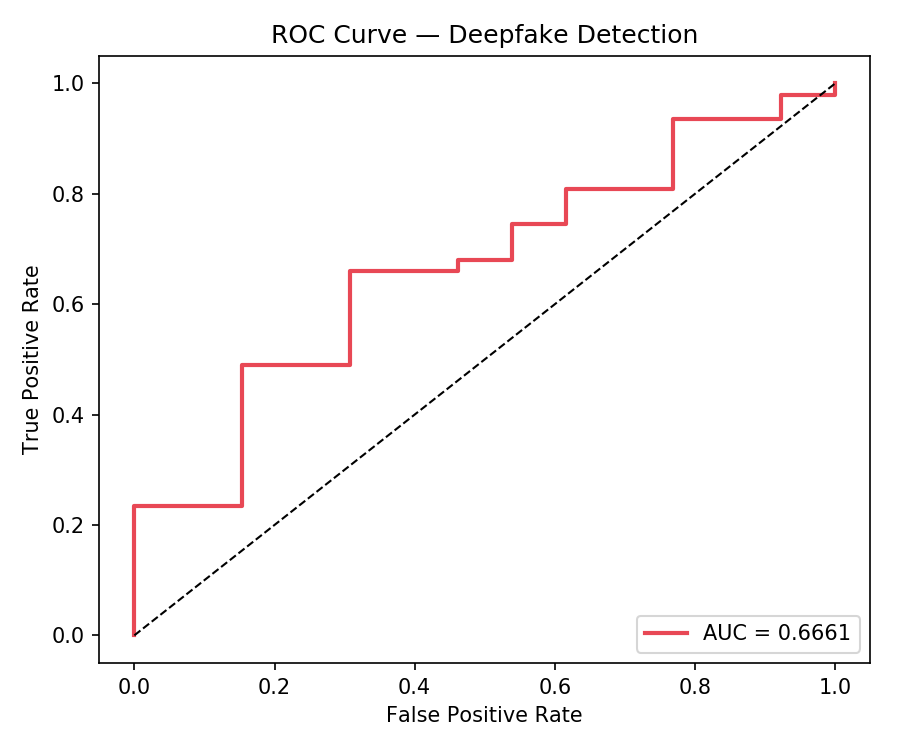

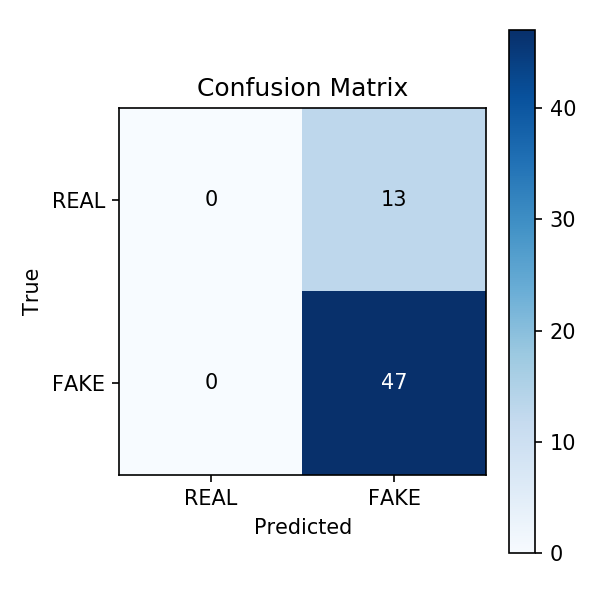

In [32]:
# ── Display plots fix for Kaggle ──────────────────────────────────────────────
from IPython.display import Image as IPImage, display

display(IPImage(str(results_dir / "val_roc_curve.png")))
display(IPImage(str(results_dir / "val_confusion_matrix.png")))

In [31]:
# Run this in your Kaggle notebook after training
# It will appear in the Output panel for download
import shutil
shutil.copy(str(best_ckpt), "/kaggle/working/best_model.pt")
print("Ready to download: /kaggle/working/best_model.pt")

Ready to download: /kaggle/working/best_model.pt
